# Introduction to Data Analysis

## What is Exploratory Data Analysis?

Exploratory Data Analysis(EDA) helps understand a dataset before applying machine learning or making decisions

### Goals of Exploratory Data Analysis
- The goal is to identify patterns, outliers, and insights

### Types of Analysis

#### 1 . Statistical Analysis
   - This involves using mathematical summaries and visualizations to understand how data behaves.

#### 2. Domain Knowledge Analysis
   - Numbers alone don’t tell the full story — domain expertise adds context and meaning

#### 3. Causality Between Features
   - Correlation is not causation just because two variables move together doesn’t mean one causes the other.This step helps you test which variables influence or drive others.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data=pd.read_csv("StudentPerformanceFactors.csv")

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

## Statistical Analysis

#### Descriptive Statistics

```python
data.describe()
```
- Provides mean, median, standard deviation, min, max, and quartiles

**What does each describe**
- **Mean**: is the average value of the dataset.
  -  _Interpretation_ :It tells you the central value of your data.
  -  _Important_:Sensitive to outliers (extreme values can skew it)
- **Median**:is the middle value when the data is sorted in order
  -  _Interpretation_:It represents the true center of the data when outliers are present.
  -  _Important_:More robust than the mean for skewed data.
- **STD**:measures how spread out the data is around the mean.
  - _Interpretation_: Small STD → data points are close to the mean
  -  _Important_:It quantifies variability or dispersion in the dataset.


In [4]:
data.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


### Distribution Analysis
- Plot histograms or boxplots to see how values are spread
```python
import seaborn as sns
sns.boxplot(x=df['numeric_column'])
sns.histplot(df['numeric_column'], bins=30)
```
### Correlation Analysis
- Check how features relate to each other numerically.
```python
df.corr(numeric_only=True)
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
```
Helps identify multicollinearity (features that are too similar)

### Group Statistics
- Use .groupby() to summarize categories.
```python
df.groupby('categorical_col')['numeric_col'].mean()
```
- Great for comparing groups or feature segments

<Axes: xlabel='Hours_Studied'>

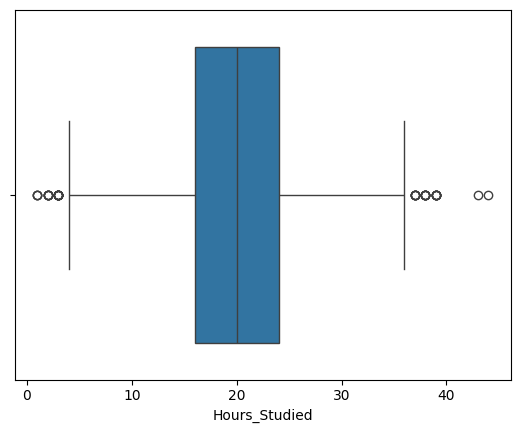

In [7]:
sns.boxplot(x=data['Hours_Studied'])

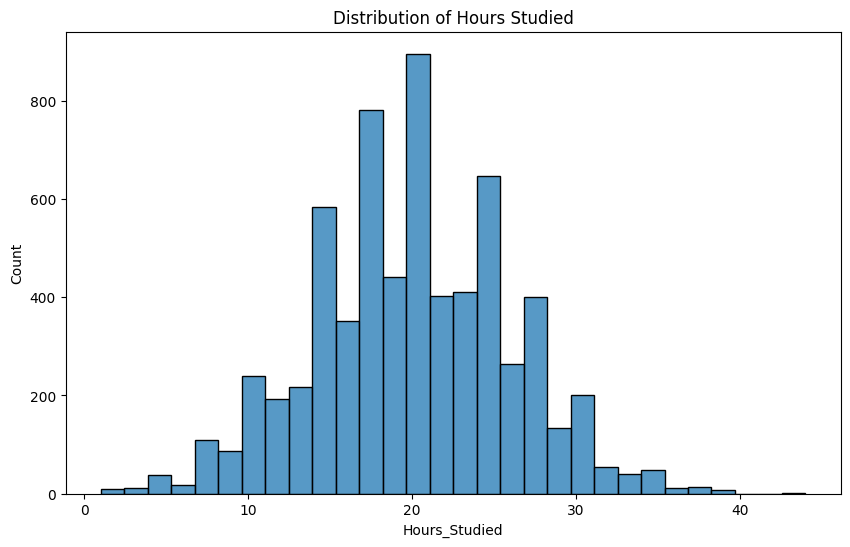

In [10]:
plt.figure(figsize=(10,6))
sns.histplot(data['Hours_Studied'], bins=30)
plt.title("Distribution of Hours Studied")
plt.show()

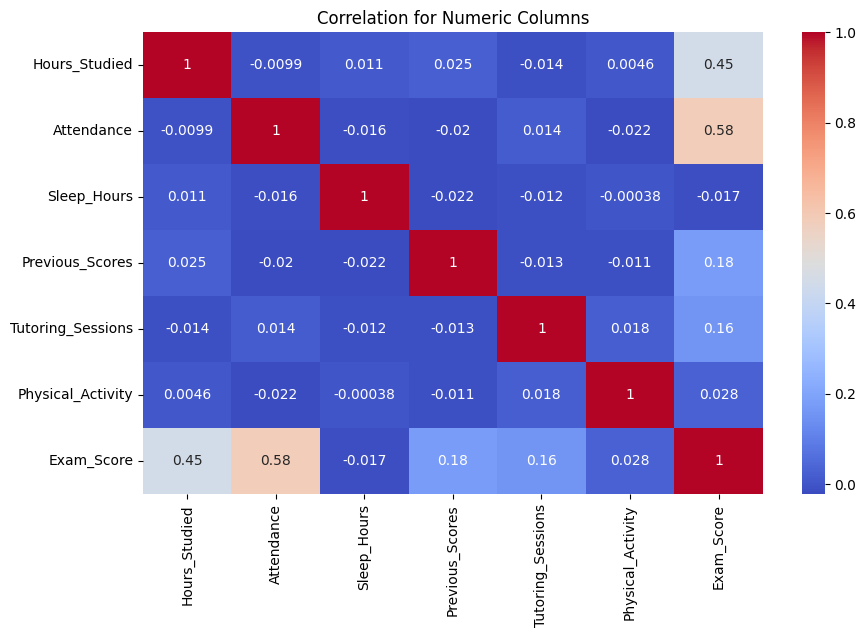

In [11]:
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation for Numeric Columns")
plt.show()

In [12]:
data.groupby('Gender')['Hours_Studied'].mean()

Gender
Female    20.005013
Male      19.953592
Name: Hours_Studied, dtype: float64

### Domain Knowledge Analysis


### Use Business Rules
- Apply thresholds or limits based on domain understanding.

### Interpret Distributions Meaningfully
 - An outlier might not always be an error  in some domains, extreme values are expected.

### Map Findings to Real-World Insights
- Don’t just summarize ,explain what the data says about your use case

## Causality Between Features
- Use Correlation as a Starting Point
- Perform Controlled Testing
 - Use scatter plots to visually test directional relationships.

### Check for Confounding Variables
 - Use hypothesis tests to verify if relationships are significant or explained by hidden variables.

#### Chi-Square Test – For Categorical Variables
- Tests if two categorical variables are independent.
- If p < 0.05, the relationship is statistically significant.

#### ANOVA (Analysis of Variance) – For Continuous vs. Categorical
- Tests if the means of multiple groups are significantly different.
- Useful for checking if a categorical feature  confounds a numeric one
- Quantifies the direction and strength of influence between variables.


In [13]:
from scipy.stats import chi2_contingency
from scipy.stats import f_oneway
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

### Chi-Square Test for Categorical Variables
**Null hypothesis (H₀):**
- The two categorical variables are independent

**Interpretation:**
- p < 0.05 → Reject H₀ → The two categorical variables are dependent
- p ≥ 0.05 → Fail to reject H₀ → no strong evidence of dependence

In [14]:
contingency_table=pd.crosstab(data['Teacher_Quality'], data['School_Type'])
chi2,p,dof,expected=chi2_contingency(contingency_table)
print(f"P-Value: {p}")

P-Value: 0.8202268906833381


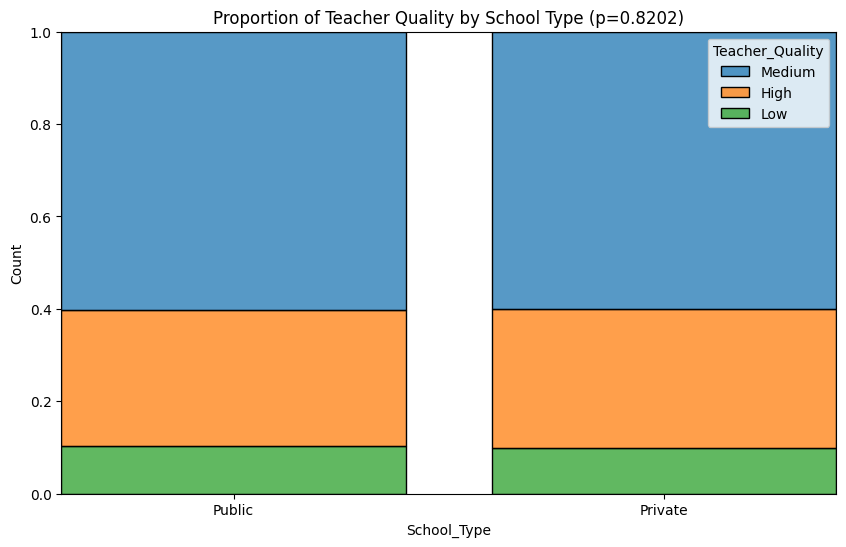

In [16]:
plt.figure(figsize=(10,6))
sns.histplot(data=data, x='School_Type', hue='Teacher_Quality',
             multiple="fill", shrink=.8)
plt.title("Proportion of Teacher Quality by School Type (p=0.8202)")
plt.show()

**Interpretation**
- **Analysis**: Since $p > 0.05$, we fail to reject the null hypothesis. There is no statistically significant association between these variables.
- **Insight**:As seen in the proportional bar chart, the distribution of teacher quality remains consistent across all school types. This suggests that School_Type is an uninformative feature for predicting teacher quality

In [26]:
contingency_table=pd.crosstab(data['Peer_Influence'], data['Extracurricular_Activities'])
chi2,p,dof,expected=chi2_contingency(contingency_table)
print(f"P-Value: {p}")

P-Value: 0.02444072995527728


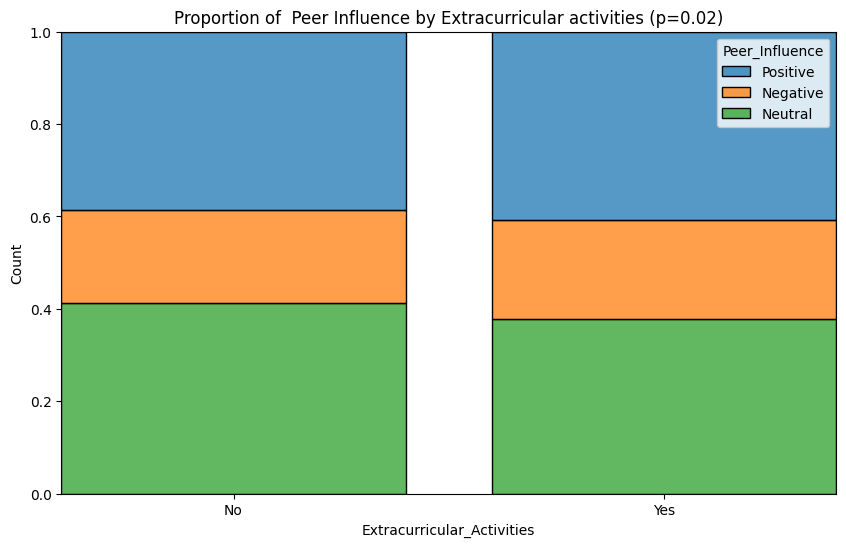

In [29]:
plt.figure(figsize=(10,6))
sns.histplot(data=data, x='Extracurricular_Activities', hue='Peer_Influence',
             multiple="fill", shrink=.8)
plt.title("Proportion of  Peer Influence by Extracurricular activities (p=0.02)")
plt.show()

**Interpretation**
- **Analysis**: Since $p<0.05$ we reject the hypothesis.There is an association between the features
- **Insight**: From the above bar chart we can see that students who particapate in extracurricular activities have more post peer influence and those not partaking generally have a neutral peer influence

###  ANOVA (Analysis of Variance) – For Continuous vs. Categorical
- Large F value → group means are very different → likely significant
- Small F value → group means are similar → likely not significant

**Null hypothesis (H₀):**
- All group means are equal

**Interpretation:**
- p < 0.05 → Reject H₀ → at least one group is different
- p ≥ 0.05 → Fail to reject H₀ → no strong evidence of difference

### Tukey's Honestly Significant Difference Test
Compares every possible pair of groups simultaneously, while controlling the risk of false positives across all those comparisons
- meandiff : how much higher group2's mean is compared to group1
- p-adj : the p-value, already adjusted for multiple comparisons
- lower / upper : the 95% confidence interval for the difference
- reject : True means this pair is significantly different


In [14]:
data['Access_to_Resources'].value_counts()

Access_to_Resources
Medium    3319
High      1975
Low       1313
Name: count, dtype: int64

In [15]:
group1 = data[data['Access_to_Resources'] == 'Medium']['Exam_Score']
group2 = data[data['Access_to_Resources'] == 'High']['Exam_Score']
group3 = data[data['Access_to_Resources'] == 'Low']['Exam_Score']

f_stat, p_val = f_oneway(group1, group2, group3)
print(f"P-Value: {p_val}")
print(f"F-Statistic: {f_stat}")

P-Value: 1.1392993838163002e-42
F-Statistic: 98.00440911486005


**Interpretation**
- The analysis revealed a statistically significant difference in exam scores between at least two groups ($F = 98.00$, $p \approx 0$),Since the p-value is significantly lower than $\alpha = 0.05$, we reject the null hypothesis
- This suggests that the level of resource access has a substantial impact on student performance


In [16]:
tukey = pairwise_tukeyhsd(
    endog=data['Exam_Score'],
    groups=data['Access_to_Resources'],
    alpha=0.05
)

print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
  High    Low  -1.8888   0.0 -2.2089 -1.5687   True
  High Medium  -0.9578   0.0 -1.2132 -0.7023   True
   Low Medium    0.931   0.0   0.638  1.2241   True
---------------------------------------------------


- There is a clear "ladder" effect. High Access > Medium Access > Low Access.

C:\Users\pales\AppData\Local\Temp\ipykernel_21036\824653637.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Access_to_Resources', y='Exam_Score', data=data, palette='viridis', order=['Low', 'Medium', 'High'])


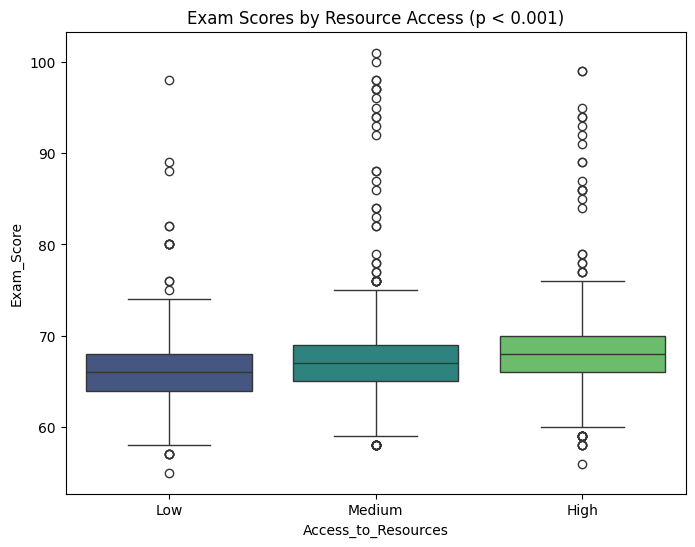

In [32]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Access_to_Resources', y='Exam_Score', data=data, palette='viridis', order=['Low', 'Medium', 'High'])
plt.title("Exam Scores by Resource Access (p < 0.001)")
plt.show()

### Confounding Variables
A confounding variable (also called a confounder) is a variable that:
- is related to your independent variable (predictor), and
- also affects your dependent variable (outcome)

Classic example: You notice that people who carry lighters are more likely to get lung cancer. Does carrying a lighter cause cancer? No , smoking is the confounder. It causes both lighter-carrying and cancer.

In [19]:
data.columns

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='str')

### Data Visualization
Data visualization is the practice of turning raw data into visual formats like charts, graphs, and dashboards so that people can understand patterns, trends, and insights quickly
#### Choosing the right visual
Different data types need different visuals:

- Line charts → trends over time
- Bar charts → comparisons between categories
- Scatter plots → relationships between variables
- Heatmaps → intensity or density patterns

#### Line Chart

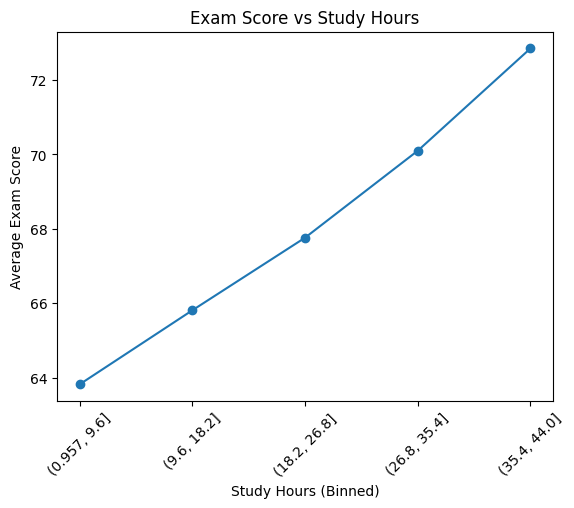

In [33]:
data['Hours_Bin'] = pd.cut(data['Hours_Studied'], bins=5)

trend = data.groupby('Hours_Bin')['Exam_Score'].mean()

plt.plot(trend.index.astype(str), trend.values, marker='o')
plt.xticks(rotation=45)
plt.xlabel("Study Hours (Binned)")
plt.ylabel("Average Exam Score")
plt.title("Exam Score vs Study Hours")
plt.show()

### Bar Chart

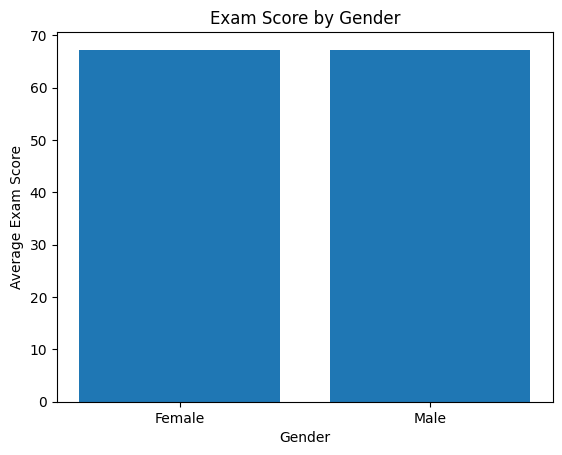

In [41]:
motivation = data.groupby('Gender')['Exam_Score'].mean()

plt.bar(motivation.index, motivation.values)
plt.xlabel("Gender")
plt.ylabel("Average Exam Score")
plt.title("Exam Score by Gender")
plt.show()

### Scatter Plot

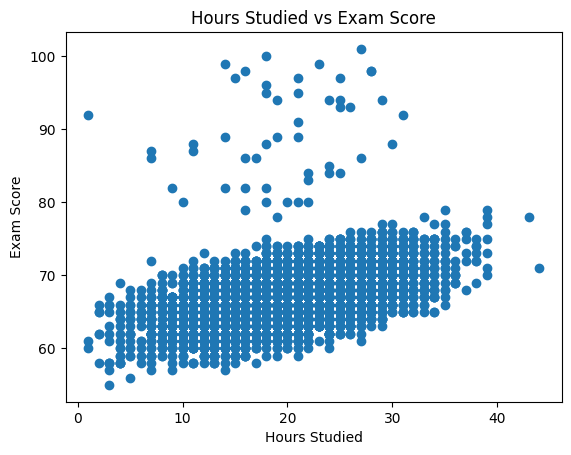

In [35]:
plt.scatter(data['Hours_Studied'], data['Exam_Score'])
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Hours Studied vs Exam Score")
plt.show()

### Pie Chart

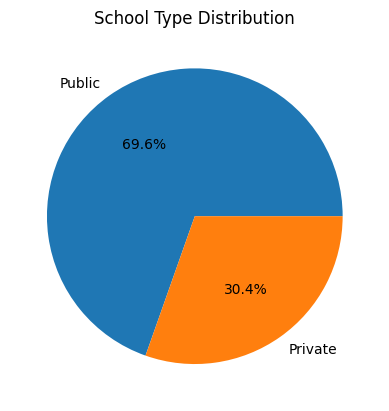

In [36]:
counts = data['School_Type'].value_counts()

plt.pie(counts, labels=counts.index, autopct='%1.1f%%')
plt.title("School Type Distribution")
plt.show()

### Histogram

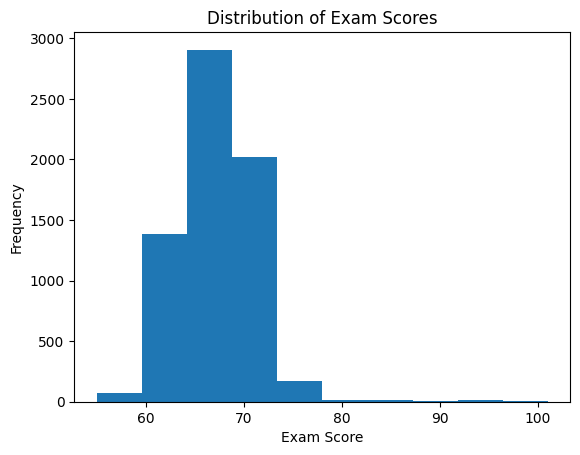

In [37]:
plt.hist(data['Exam_Score'], bins=10)
plt.xlabel("Exam Score")
plt.ylabel("Frequency")
plt.title("Distribution of Exam Scores")
plt.show()

### Pair Plot

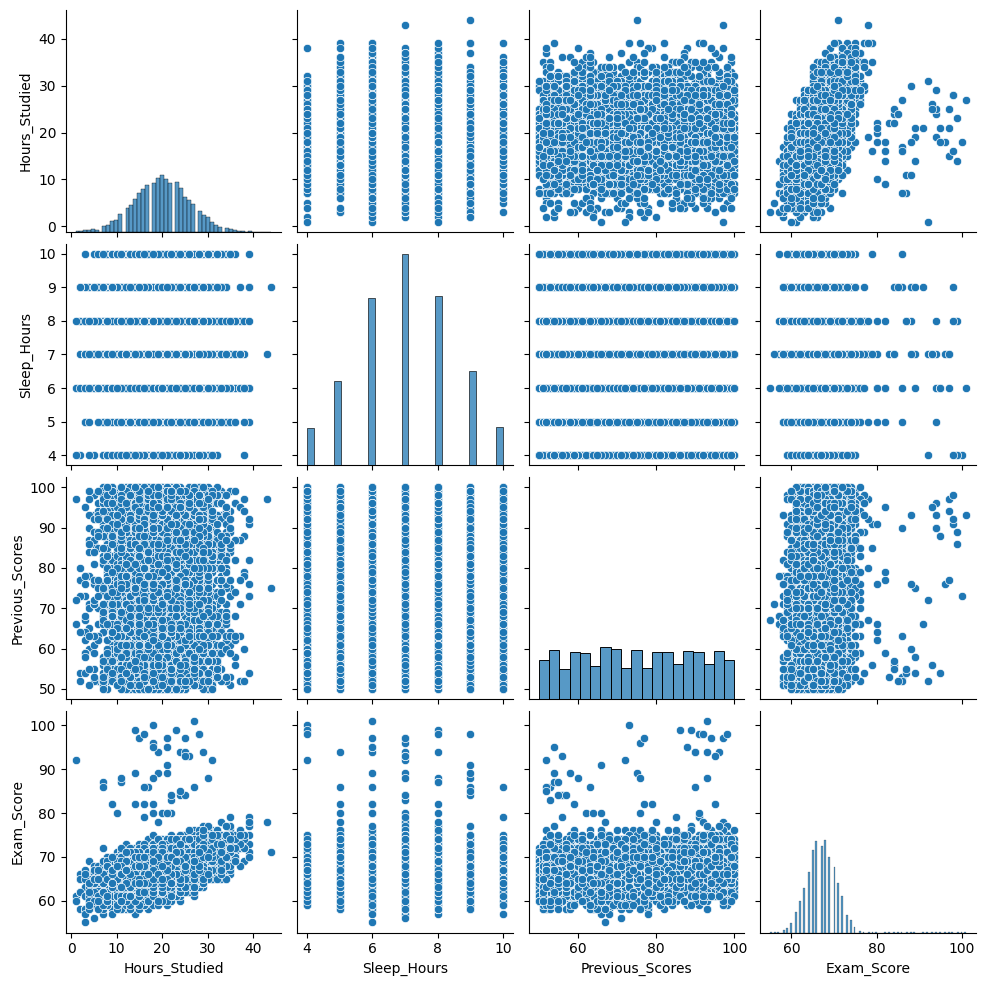

In [39]:
sns.pairplot(data[['Hours_Studied', 'Sleep_Hours', 'Previous_Scores', 'Exam_Score']])
plt.show()

#### Bivariate Plots (2 variables)

These show the relationship between one independent variable and one dependent variable

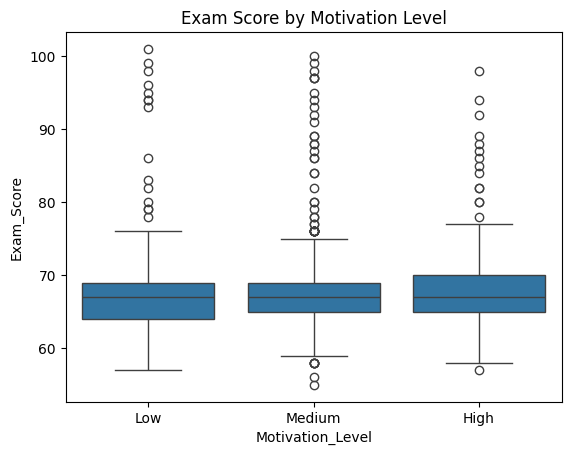

In [42]:
sns.boxplot(x='Motivation_Level', y='Exam_Score', data=data)
plt.title("Exam Score by Motivation Level")
plt.show()

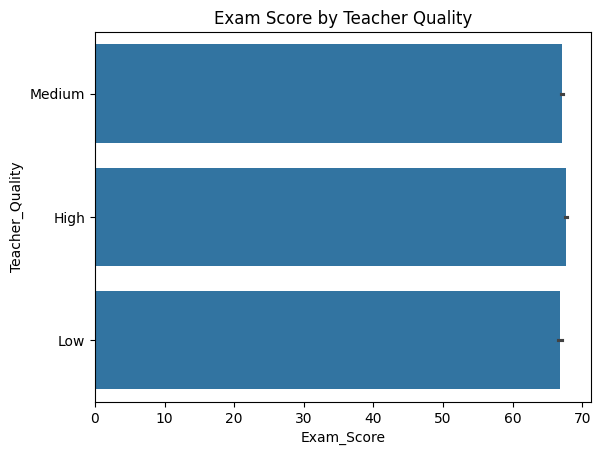

In [50]:
sns.barplot(
    y='Teacher_Quality',
    x='Exam_Score',
    data=data
)

plt.title("Exam Score by Teacher Quality")
plt.show()

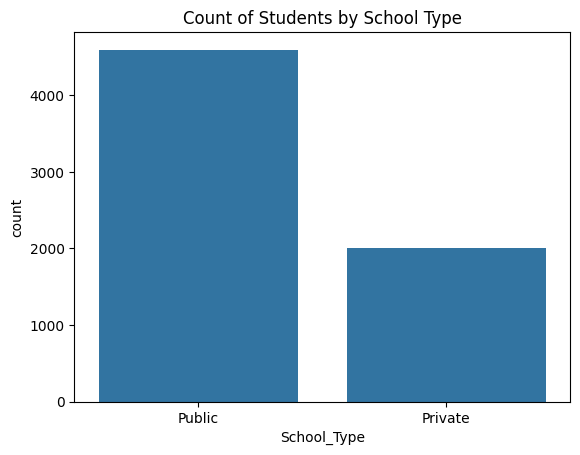

In [51]:
sns.countplot(
    x='School_Type',
    data=data
)

plt.title("Count of Students by School Type")
plt.show()

#### Multivariate Plots (3+ variables)
These reveal interactions between multiple factors.

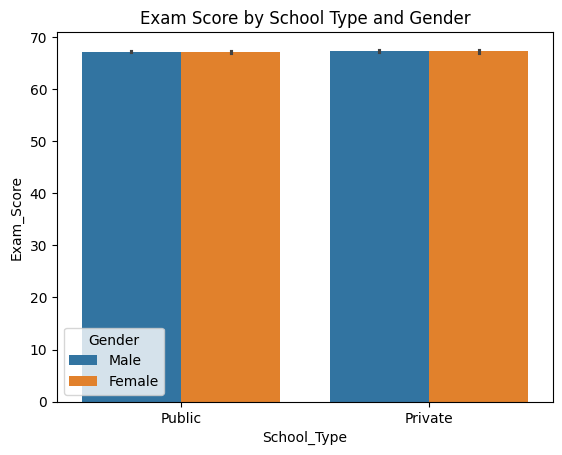

In [44]:
sns.barplot(
    x='School_Type',
    y='Exam_Score',
    hue='Gender',
    data=data
)

plt.title("Exam Score by School Type and Gender")
plt.show()

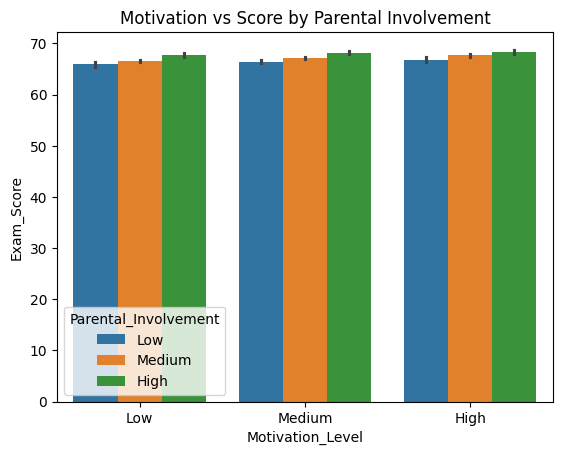

In [45]:
sns.barplot(
    x='Motivation_Level',
    y='Exam_Score',
    hue='Parental_Involvement',
    data=data
)

plt.title("Motivation vs Score by Parental Involvement")
plt.show()

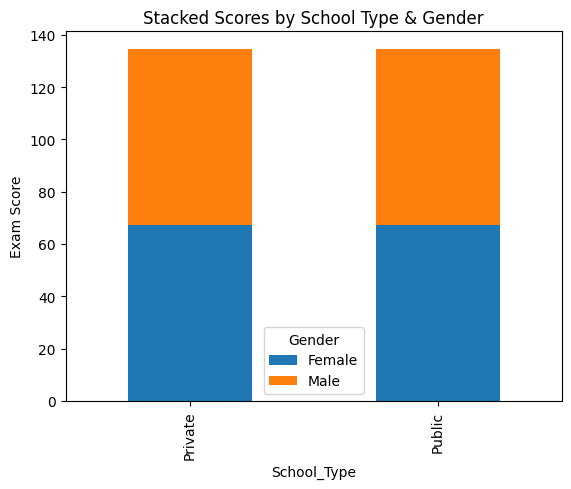

In [47]:
pivot = data.pivot_table(
    values='Exam_Score',
    index='School_Type',
    columns='Gender',
    aggfunc='mean'
)

pivot.plot(kind='bar', stacked=True)

plt.title("Stacked Scores by School Type & Gender")
plt.ylabel("Exam Score")
plt.show()

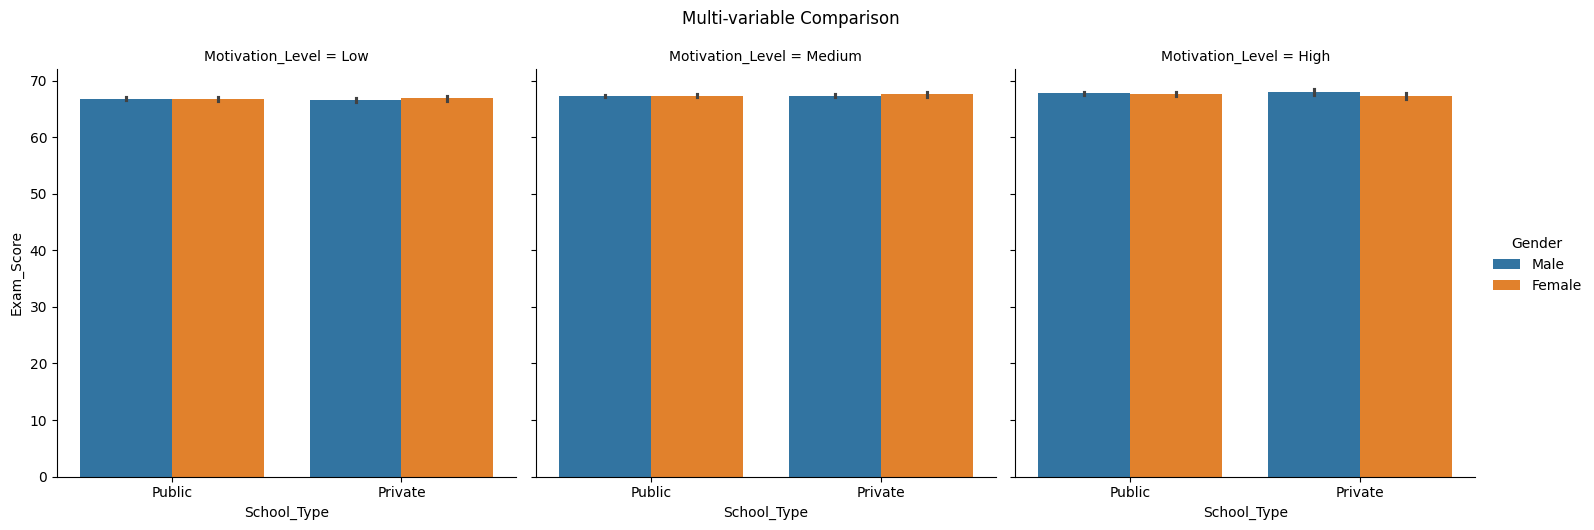

In [48]:
g = sns.catplot(
    x='School_Type',
    y='Exam_Score',
    hue='Gender',
    col='Motivation_Level',
    kind='bar',
    data=data
)

g.fig.suptitle("Multi-variable Comparison", y=1.05)
plt.show()

- Now that you know the full EDA pipeline,it is time you work on a full dataset and do the following:
    - Clean your data
    - Do analysis
    - Visualize and make recommendations